# Project Metrics

Run after completing Signal and Image notebooks.

**Cell 1** — Training curve viewer for a single image model run. Set  to match the run number used in the Image notebook.

**Cell 2** — Comparison plot (macro AUROC per epoch) for all three models. Set , ,  to match the  values used in each notebook run.
- Signal metrics: 
- Image metrics:  

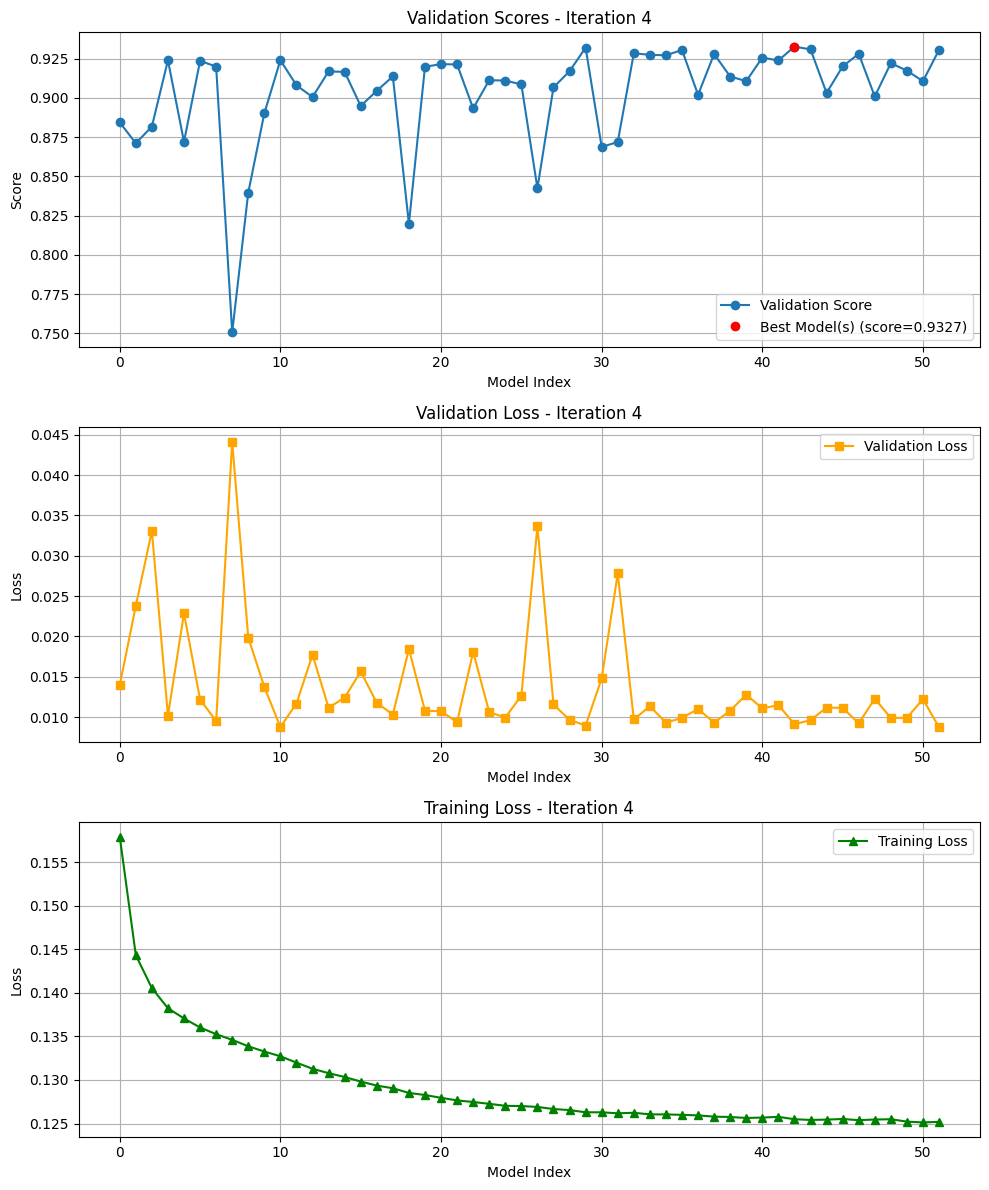

[0.884357 0.871096 0.881703 0.923941 0.871991 0.923563 0.919966 0.750518
 0.839622 0.890141 0.924021 0.908031 0.900511 0.916876 0.916553 0.894807
 0.904507 0.913639 0.819788 0.919811 0.921506 0.921273 0.89328  0.91126
 0.911029 0.908563 0.842388 0.906685 0.916988 0.932001 0.868718 0.871866
 0.928388 0.927438 0.927138 0.930501 0.90197  0.92796  0.913577 0.910686
 0.925679 0.923826 0.932657 0.930887 0.903133 0.920015 0.928108 0.900877
 0.922131 0.917321 0.910613 0.930603]


In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Use a proper file path - removed the leading slash which would look in root directory
# Added path variable for clarity
file_path = "record_history/metrics.h5"

try:
    # Open the file with context manager for automatic closing
    with h5py.File(file_path, "a") as mh5:
        # Assuming 'iter' is defined somewhere - if not, you need to specify it
        # iter = some_value  # Uncomment and set this to your iteration value
        
        iter = 9  # match iter_kd from Image notebook Cell 22
        
        # Check if datasets exist before accessing
        score_key = f"valid_score_{iter}"
        loss_key = f"valid_loss_{iter}"
        train_loss_key = f"train_loss_{iter}"
        
        if score_key not in mh5:
            raise KeyError(f"Dataset {score_key} not found in {file_path}")
        if loss_key not in mh5:
            raise KeyError(f"Dataset {loss_key} not found in {file_path}")
        if train_loss_key not in mh5:
            raise KeyError(f"Dataset {train_loss_key} not found in {file_path}")
        
        # Read data
        score_list = mh5[score_key][()]
        valid_loss_list = mh5[loss_key][()]
        train_loss_list = mh5[train_loss_key][()]
        
        # Find best model (handling cases where max might occur multiple times)
        max_score = np.max(score_list)
        best_model_indices = np.where(score_list == max_score)[0]
        
        # Create figure with subplots for better organization
        fig, axes = plt.subplots(3, 1, figsize=(10, 12))
        
        # Plot 1: Validation Scores
        axes[0].plot(score_list, marker='o', linestyle='-', label='Validation Score')
        axes[0].plot(best_model_indices, score_list[best_model_indices], 'ro', 
                     label=f'Best Model(s) (score={max_score:.4f})')
        axes[0].set_title(f'Validation Scores - Iteration {iter}')
        axes[0].set_xlabel('Model Index')
        axes[0].set_ylabel('Score')
        axes[0].grid(True)
        axes[0].legend()
        
        # Plot 2: Validation Loss
        axes[1].plot(valid_loss_list, marker='s', linestyle='-', color='orange', label='Validation Loss')
        axes[1].set_title(f'Validation Loss - Iteration {iter}')
        axes[1].set_xlabel('Model Index')
        axes[1].set_ylabel('Loss')
        axes[1].grid(True)
        axes[1].legend()
        
        # Plot 3: Training Loss
        axes[2].plot(train_loss_list, marker='^', linestyle='-', color='green', label='Training Loss')
        axes[2].set_title(f'Training Loss - Iteration {iter}')
        axes[2].set_xlabel('Model Index')
        axes[2].set_ylabel('Loss')
        axes[2].grid(True)
        axes[2].legend()
        
        plt.tight_layout()
        plt.show()
        
        print(score_list)
        
except FileNotFoundError:
    print(f"Error: File {file_path} not found.")
except KeyError as e:
    print(f"Error: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

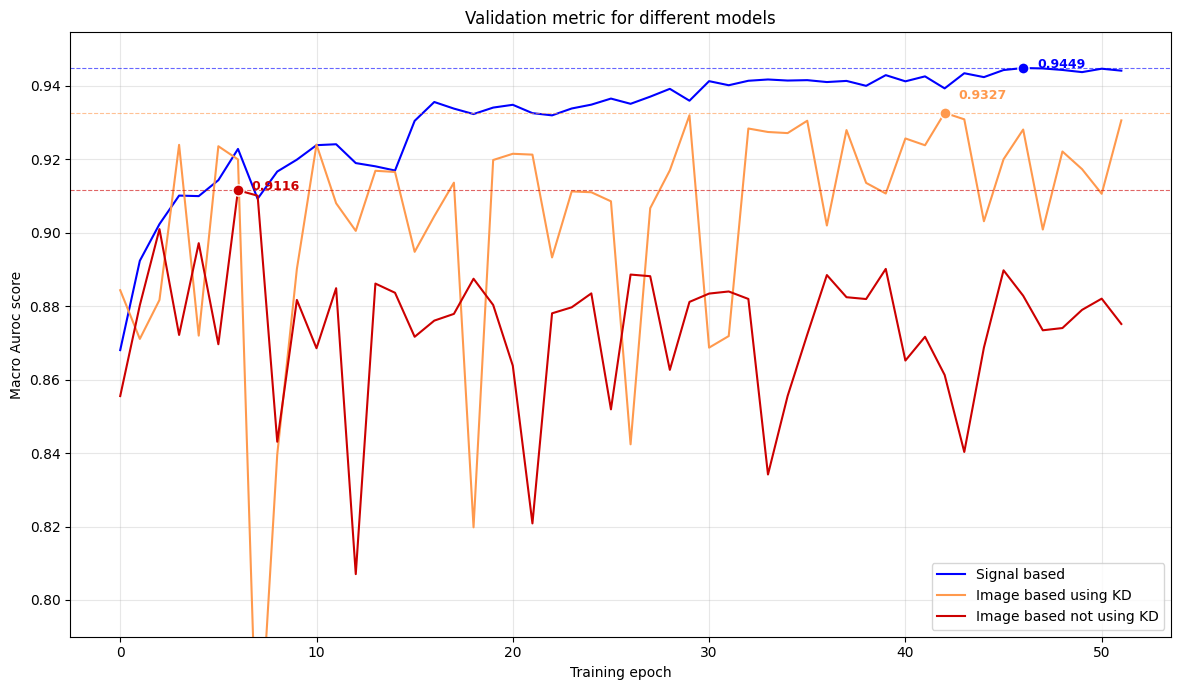

Best scores:
Signal based: 0.944859 at epoch 46
Image based using KD: 0.932657 at epoch 42
Image based not using KD: 0.911577 at epoch 6


In [41]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Configure which training runs to compare ──────────────────────────────
# These should match the 'iter' value set in each notebook's parameter cell.
iter_signal = 10   # iter used in Signal notebook (Cell 32)
iter_kd   = 9   # iter used in Image notebook (using_kd=True)    # iter used in Image notebook with using_kd=True  (Cell 22)
iter_nokd = 8   # iter used in Image notebook (using_kd=False)    # iter used in Image notebook with using_kd=False (Cell 22)
# Note: if KD and no-KD were run as separate iter values, set them individually.

signal_h5  = 'record_history/metrics_signal.h5'
image_h5   = 'record_history/metrics.h5'

# ── Load data ──────────────────────────────────────────────────────────────
def load_scores(h5_path, iter_val):
    """Return valid_score array for the given iter, or None if not found."""
    if not os.path.exists(h5_path):
        print(f'Missing: {h5_path}')
        return None
    with h5py.File(h5_path, 'r') as f:
        key = f'valid_score_{iter_val}'
        if key not in f:
            print(f'Key {key!r} not found in {h5_path}. Available: {list(f.keys())}')
            return None
        return f[key][()]

score_signal = load_scores(signal_h5, iter_signal)
score_kd     = load_scores(image_h5,  iter_kd)

# no-KD may be a different iter or the same file
if iter_nokd != iter_kd:
    score_nokd = load_scores(image_h5, iter_nokd)
else:
    # Same iter — can only be one run; skip no-KD unless a different iter was used
    score_nokd = None
    print(f'iter_nokd == iter_kd ({iter_nokd}); set iter_nokd to a different value if you ran a no-KD training.')

# ── Plot ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 7))

lines, best_info = [], []

if score_signal is not None:
    line, = plt.plot(score_signal, label='Signal based', color='blue')
    best_i = int(np.argmax(score_signal))
    lines.append((line, score_signal, best_i))
    best_info.append(('Signal based', score_signal[best_i], best_i))

if score_kd is not None:
    line, = plt.plot(score_kd, label='Image based using KD', color=[1.0, 0.6, 0.3])
    best_i = int(np.argmax(score_kd))
    lines.append((line, score_kd, best_i))
    best_info.append(('Image based using KD', score_kd[best_i], best_i))

if score_nokd is not None:
    line, = plt.plot(score_nokd, label='Image based not using KD', color=[0.8, 0, 0])
    best_i = int(np.argmax(score_nokd))
    lines.append((line, score_nokd, best_i))
    best_info.append(('Image based not using KD', score_nokd[best_i], best_i))

if not lines:
    print('No data to plot. Run the Signal and Image notebooks first.')
else:
    for line, scores, best_i in lines:
        color = line.get_color()
        best_score = scores[best_i]
        plt.axhline(y=best_score, color=color, linestyle='--', alpha=0.6, linewidth=0.8)
        plt.plot(best_i, best_score, 'o', color=color, markersize=8,
                 markeredgecolor='white', markeredgewidth=1)
        plt.annotate(f'{best_score:.4f}',
                     xy=(best_i, best_score),
                     xytext=(10, 5),
                     textcoords='offset points',
                     color=color, fontweight='bold', fontsize=9)

    plt.title('Validation metric for different models')
    plt.xlabel('Training epoch')
    plt.ylabel('Macro AUROC score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(bottom=min(0.6, min(s.min() for _, s, _ in lines) - 0.02))
    plt.tight_layout()
    plt.show()

    print('
Best scores:')
    for label, score, epoch in best_info:
        print(f'  {label}: {score:.6f} at epoch {epoch}')
